In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter, adspdfe
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
import numpy as np

def coloredNoisePsdShape(alpha, n_fft):
    """|S(e^jw)|^2 = k' |w|^(3/2), k' = 10^-1.5"""
    w = np.linspace(-np.pi, np.pi, n_fft, endpoint=False)
    psd = alpha * np.abs(w) ** 1.5
    # Handle DC to avoid zero-power issues if needed, 
    # though for positive exponents 0 is fine.
    psd[0] = psd[1] if n_fft > 1 else alpha
    return np.fft.ifftshift(np.sqrt(psd))

def genEqFirRlsBpsk(
    n_samples,
    h_ch,
    eq_order=50,
    delay=None,
    noise_alpha=10**(-1.5),
    rng=None,
    n_fft=None,
):
    """
    Generates the input 'u' and desired 'd' for Problem 20/21.
    Aligns the training sequence based on the channel peak and filter delay.
    """
    if rng is None:
        rng = np.random.default_rng()

    h_ch = np.asarray(h_ch, dtype=np.float64)
    ch_len = len(h_ch)
    
    # Total number of filter taps (M)
    M = eq_order + 1

    # Default delay: usually mid-channel + mid-filter for best MSE
    if delay is None:
        # For your specific channel, the peak is near the end (index 19)
        # Choosing a delay that 'centers' the main energy in the filter.
        delay = 19 

    # We need enough padding to account for convolution tail and delays
    pad = delay + M + ch_len + 10
    total_len = n_samples + pad

    # 1. Generate Binary Training Signal x[n] \in {-1, +1}
    x = rng.choice([-1.0, 1.0], size=total_len)

    # 2. Channel Filtering: s[n] = x[n] * h[n]
    s = np.convolve(x, h_ch, mode='full')[:total_len]

    # 3. Generate Colored Gaussian Noise
    if n_fft is None:
        # Next power of 2 for efficient FFT
        n_fft = 1 << (total_len - 1).bit_length()

    # White noise in frequency domain
    G = np.fft.fft(rng.normal(size=n_fft))
    # Shape it with |w|^0.75
    shaping_kernel = coloredNoisePsdShape(noise_alpha, n_fft)
    # Time domain colored noise
    noise = np.fft.ifft(G * shaping_kernel).real[:total_len]

    # 4. Received Signal r[n]
    r = s + noise

    # 5. Alignment for Adaptive Filtering
    # The 'start' index ensures the filter has enough history (M samples)
    start = M 
    stop = start + n_samples
    
    # u: The input the equalizer sees
    u = r[start:stop]
    
    # d: The ground truth bits we want the equalizer to output.
    # We look back by 'delay' samples into the original sequence 'x'.
    d = x[start - delay : stop - delay]

    return u, d, x, r

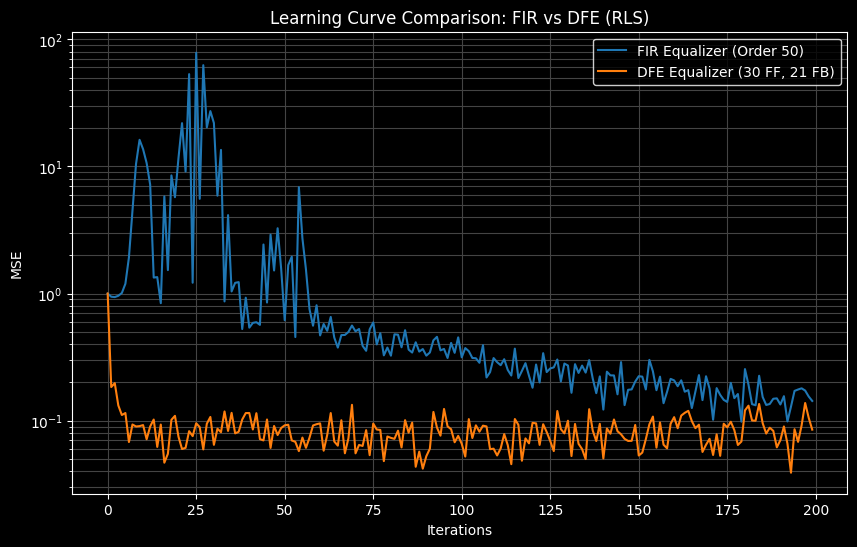

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Channel Impulse Response
h20 = np.array([
    -0.001, -0.002, 0.002, 0.2, 0.6, 0.76, 0.9, 0.78, 0.67, 0.58,
    0.45, 0.3, 0.2, 0.12, 0.06, 0.0, -0.2, -1.0, -2.0, -10.0, 0.1
])

# Configuration
n_samples = 200
n_ens = 30  # Ensemble runs for smooth curves
order_fir = 50
n_ff, n_fb = 30, 21 # DFE total taps = 51

# Initialize Models
fir_rls = adspfilter.RLS(filter_order=order_fir, lam=0.99, delta=0.01)
dfe_rls = adspdfe.RlsDfe(n_ff=n_ff, n_fb=n_fb, lam=0.99, delta=0.01)

mse_fir = np.zeros(n_samples)
mse_dfe = np.zeros(n_samples)

for ens in range(n_ens):
    u, d, _, _ = genEqFirRlsBpsk(n_samples, h20, eq_order=order_fir)
    
    # FIR Run
    _, e_fir, _ = fir_rls(u, d, train=True)
    mse_fir += np.abs(e_fir)**2
    fir_rls.w[:] = 0 # Reset for next ensemble
    
    # DFE Run
    _, e_dfe = dfe_rls(u, d, train=True)
    mse_dfe += np.abs(e_dfe)**2
    dfe_rls.resetAllStates()

# Plotting Learning Curves
plt.figure(figsize=(10, 6))
plt.semilogy(mse_fir / n_ens, label='FIR Equalizer (Order 50)')
plt.semilogy(mse_dfe / n_ens, label='DFE Equalizer (30 FF, 21 FB)')
plt.title("Learning Curve Comparison: FIR vs DFE (RLS)")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, which='both')
plt.show()

In [20]:
import numpy as np


def genEqFirRls4Qam(n_coef=10, lam=0.98):
  # --- 1. Signal Generation ---
  n_samples = 3000
  # 4-QAM mapping: (±1 ± j) / sqrt(2) for unit power
  constellation = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)
  s = np.random.choice(constellation, size=n_samples + 10)
  
  # --- 2. Channel H(z) ---
  # H(z) = (0.34 - 0.27j) + (0.87 + 0.43j)z^-1 + (0.34 - 0.21j)z^-2
  h_complex = np.array([0.34 - 0.27j, 0.87 + 0.43j, 0.34 - 0.21j])
  
  # Received signal without noise (tilde{x})
  x_clean = np.convolve(s, h_complex, mode='valid')[:n_samples]
  
  # --- 3. Noise Addition (SNR = 20) ---
  sig_power = np.mean(np.abs(x_clean)**2)
  noise_power = sig_power / 20
  # Complex Gaussian noise: divide power by 2 for real/imag parts
  noise = np.sqrt(noise_power / 2) * (np.random.randn(n_samples) + 1j * np.random.randn(n_samples))
  u = x_clean + noise
  
  # --- 4. RLS Setup ---
  # We need a small delay (Delta) to account for the channel group delay.
  # For a 3-tap channel, a delay of 1 or 2 is usually optimal.
  delay = 2
  d = s[delay : delay + n_samples]
  
  # Initialize your RLS engine
  # filter_order = n_coef - 1
  rls = adspfilter.RLS(filter_order=n_coef - 1, lam=lam, delta=0.1)
  
  # Run the algorithm
  y, e, w_hist = rls(u, d, train=True)
  
  return u, y, e


# Execute for part (b) and (c)
u10, y10, e10 = genEqFirRls4Qam(n_coef=10, lam=0.97)
u20, y20, e20 = genEqFirRls4Qam(n_coef=20, lam=0.97)

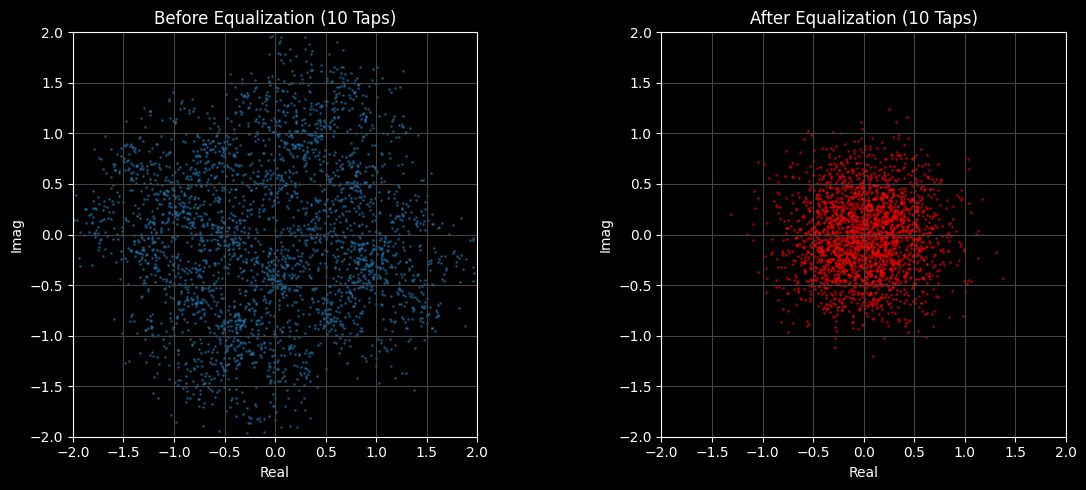

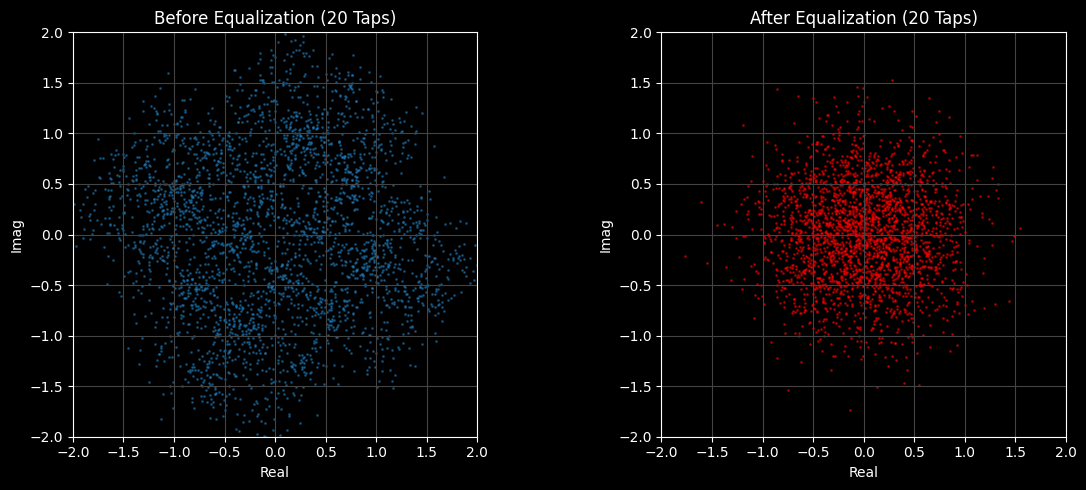

In [21]:
def plotConstellation(u, y, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Before Equalization
    ax[0].scatter(u.real, u.imag, s=1, alpha=0.5)
    ax[0].set_title(f"Before Equalization {title}")
    ax[0].set_xlabel("Real")
    ax[0].set_ylabel("Imag")
    
    # After Equalization (Discard first 500 samples for convergence)
    ax[1].scatter(y[500:].real, y[500:].imag, s=1, color='red', alpha=0.5)
    ax[1].set_title(f"After Equalization {title}")
    ax[1].set_xlabel("Real")
    ax[1].set_ylabel("Imag")
    
    for a in ax:
        a.grid(True)
        a.set_xlim([-2, 2])
        a.set_ylim([-2, 2])
        a.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# (b) Plot for 10 coefficients
plotConstellation(u10, y10, "(10 Taps)")

# (c) Plot for 20 coefficients
plotConstellation(u20, y20, "(20 Taps)")

Comparison of 10 vs. 20 Coefficients:

In the plots for (c), you will likely notice that increasing the coefficients to 20 provides diminishing returns. Because the channel $H(z)$ only has 3 taps and the SNR is limited to 20 dB, a 10-tap filter is already sufficient to invert the ISI. The remaining "fuzziness" in the 20-tap constellation is primarily due to the additive noise, which linear equalization cannot remove.